In [1]:
# ============================================
# 1. IMPORT ALL REQUIRED LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Feature Selection
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold, RFE, SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier

# Handling Imbalance
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

# Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, matthews_corrcoef
)

# Hyperparameter Tuning
import optuna
from optuna.samplers import TPESampler
from optuna.visualization import plot_optimization_history, plot_param_importances

# Visualization & Explainability
import shap
import gc  # Garbage collection for memory management

# Set display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✅ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")


✅ All libraries imported successfully!
Pandas version: 3.0.3


In [11]:
# ============================================
# 2. LOAD AND EXPLORE THE DATASET
# ============================================

# Load the data - optimized for large file
print("Loading dataset...")
df = pd.read_csv('DataSet.csv', low_memory=False)  # Update path as needed

print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Identify target column (last column: F3925)
target_col = df.columns[-1]
print(f"\nTarget column: {target_col}")
print(f"Target unique values: {df[target_col].unique()}")

# Target distribution
target_dist = df[target_col].value_counts()
print(f"\nTarget distribution:")
for val, count in target_dist.items():
    print(f"  Class {val}: {count:,} ({count/len(df)*100:.2f}%)")

# Check class imbalance ratio
minority_pct = (target_dist.min() / target_dist.sum()) * 100
print(f"\n⚠️ Class Imbalance Ratio: {minority_pct:.2f}% minority class")

# Check for missing values (sample to save time)
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100
cols_with_missing = missing_counts[missing_counts > 0]
print(f"\nColumns with missing values: {len(cols_with_missing)}")
print(f"Columns with >50% missing: {(missing_percent > 50).sum()}")

# Drop index column if it exists
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)
    print("\n✅ Dropped 'Unnamed: 0' column")

# Sample for quick EDA (optional - use first 5000 rows for faster processing)
# df_sample = df.head(5000)  # Uncomment if needed for faster prototyping

print("\n" + "=" * 70)
print("DATA TYPES DISTRIBUTION")
print("=" * 70)
print(df.dtypes.value_counts())

Loading dataset...
DATASET OVERVIEW
Shape: 9,082 rows × 3,925 columns
Memory usage: 275.15 MB

Target column: F3924
Target unique values: [0 1]

Target distribution:
  Class 0: 9,001 (99.11%)
  Class 1: 81 (0.89%)

⚠️ Class Imbalance Ratio: 0.89% minority class

Columns with missing values: 3835
Columns with >50% missing: 1138

✅ Dropped 'Unnamed: 0' column

DATA TYPES DISTRIBUTION
float64    3876
int64        40
str           8
Name: count, dtype: int64


### 3. DATA CLEANING & PREPROCESSING


In [18]:
# ============================================
# 3. DATA CLEANING & PREPROCESSING
# ============================================

def clean_and_preprocess(df, target_col, sample_size=None):
    """
    Complete data cleaning and preprocessing pipeline
    Memory efficient for large datasets
    """
    
    print("\n" + "=" * 70)
    print("PREPROCESSING PIPELINE")
    print("=" * 70)
    
    df_clean = df.copy()
    
    # Separate features and target
    X = df_clean.drop(target_col, axis=1)
    y = df_clean[target_col]
    
    print(f"Features shape: {X.shape}")
    print(f"Target shape: {y.shape}")
    
    # Identify column types
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    
    print(f"\nNumeric columns: {len(numeric_cols):,}")
    print(f"Categorical columns: {len(categorical_cols):,}")
    
    # Remove fully-null numeric columns

    all_nan_numeric_cols = [
        col for col in numeric_cols
        if X[col].isnull().all()
    ]

    print(
        f"Removing {len(all_nan_numeric_cols)} fully-null numeric columns"
    )

    X = X.drop(columns=all_nan_numeric_cols)

    # recompute numeric columns
    numeric_cols = X.select_dtypes(
        include=[np.number]
    ).columns.tolist()

    print("\n📊 Imputing numeric columns...")

    numeric_imputer = SimpleImputer(
        strategy='median'
    )
    X_numeric = pd.DataFrame(
        numeric_imputer.fit_transform(X[numeric_cols]),
        columns=numeric_cols,
        index=X.index
    )
    print(f"  ✅ Completed numeric imputation")
    
    # Handle categorical columns
    if categorical_cols:
        print(f"\n📊 Processing {len(categorical_cols)} categorical columns...")
        categorical_imputer = SimpleImputer(strategy='constant', fill_value='MISSING')
        X_categorical_imputed = pd.DataFrame(
            categorical_imputer.fit_transform(X[categorical_cols]),
            columns=categorical_cols,
            index=X.index
        )
        
        # One-hot encode categorical columns
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        X_categorical_encoded = pd.DataFrame(
            encoder.fit_transform(X_categorical_imputed),
            columns=encoder.get_feature_names_out(categorical_cols),
            index=X.index
        )
        print(f"  ✅ One-hot encoding completed: {X_categorical_encoded.shape[1]} features")
        
        # Combine numeric and encoded categorical
        X_processed = pd.concat([X_numeric, X_categorical_encoded], axis=1)
    else:
        X_processed = X_numeric
    
    # Remove constant and quasi-constant features
    print("\n📊 Removing constant features...")
    variance_threshold = VarianceThreshold(threshold=0.01)
    X_processed_vars = variance_threshold.fit_transform(X_processed)
    constant_removed = X_processed.shape[1] - X_processed_vars.shape[1]
    X_processed = pd.DataFrame(
        X_processed_vars,
        columns=X_processed.columns[variance_threshold.get_support()],
        index=X_processed.index
    )
    print(f"  ✅ Removed {constant_removed} constant/quasi-constant features")
    
    # Memory cleanup
    gc.collect()
    
    print(f"\n✅ Final preprocessed shape: {X_processed.shape[1]:,} features")
    print(f"✅ Memory usage: {X_processed.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    return X_processed, y

# Run preprocessing
X_processed, y = clean_and_preprocess(df, target_col)

# Verify no data loss
print(f"\n✓ Preprocessing complete. X: {X_processed.shape}, y: {y.shape}")
print(f"✓ Target distribution after preprocessing:\n{y.value_counts()}")


PREPROCESSING PIPELINE
Features shape: (9082, 3923)
Target shape: (9082,)

Numeric columns: 3,915
Categorical columns: 8
Removing 63 fully-null numeric columns

📊 Imputing numeric columns...
  ✅ Completed numeric imputation

📊 Processing 8 categorical columns...
  ✅ One-hot encoding completed: 4337 features

📊 Removing constant features...
  ✅ Removed 5220 constant/quasi-constant features

✅ Final preprocessed shape: 2,969 features
✅ Memory usage: 205.72 MB

✓ Preprocessing complete. X: (9082, 2969), y: (9082,)
✓ Target distribution after preprocessing:
F3924
0    9001
1      81
Name: count, dtype: int64


### 4. EXPLORATORY DATA ANALYSIS


EXPLORATORY DATA ANALYSIS


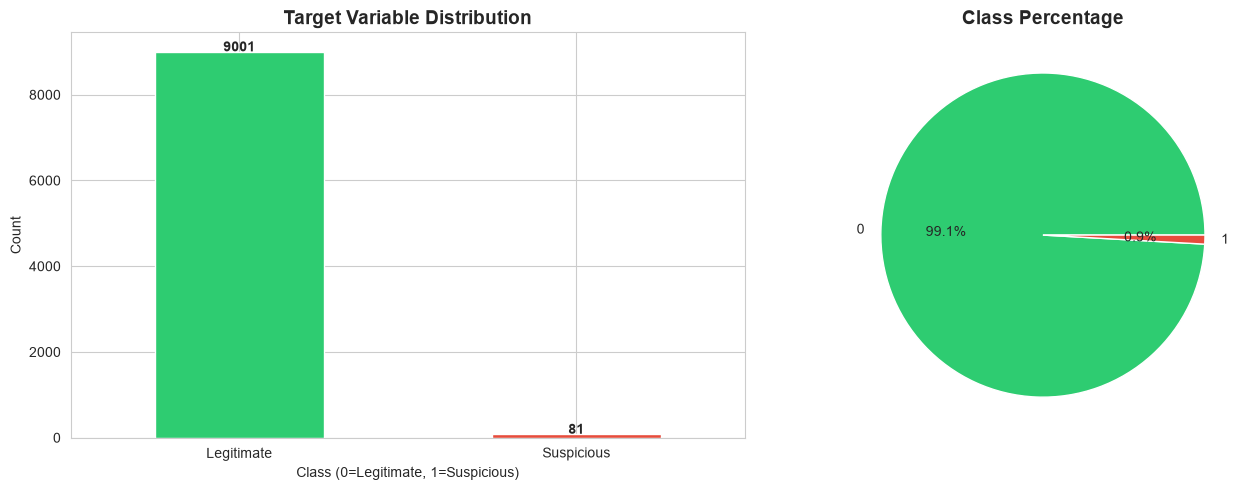


📊 Analyzing feature distributions...


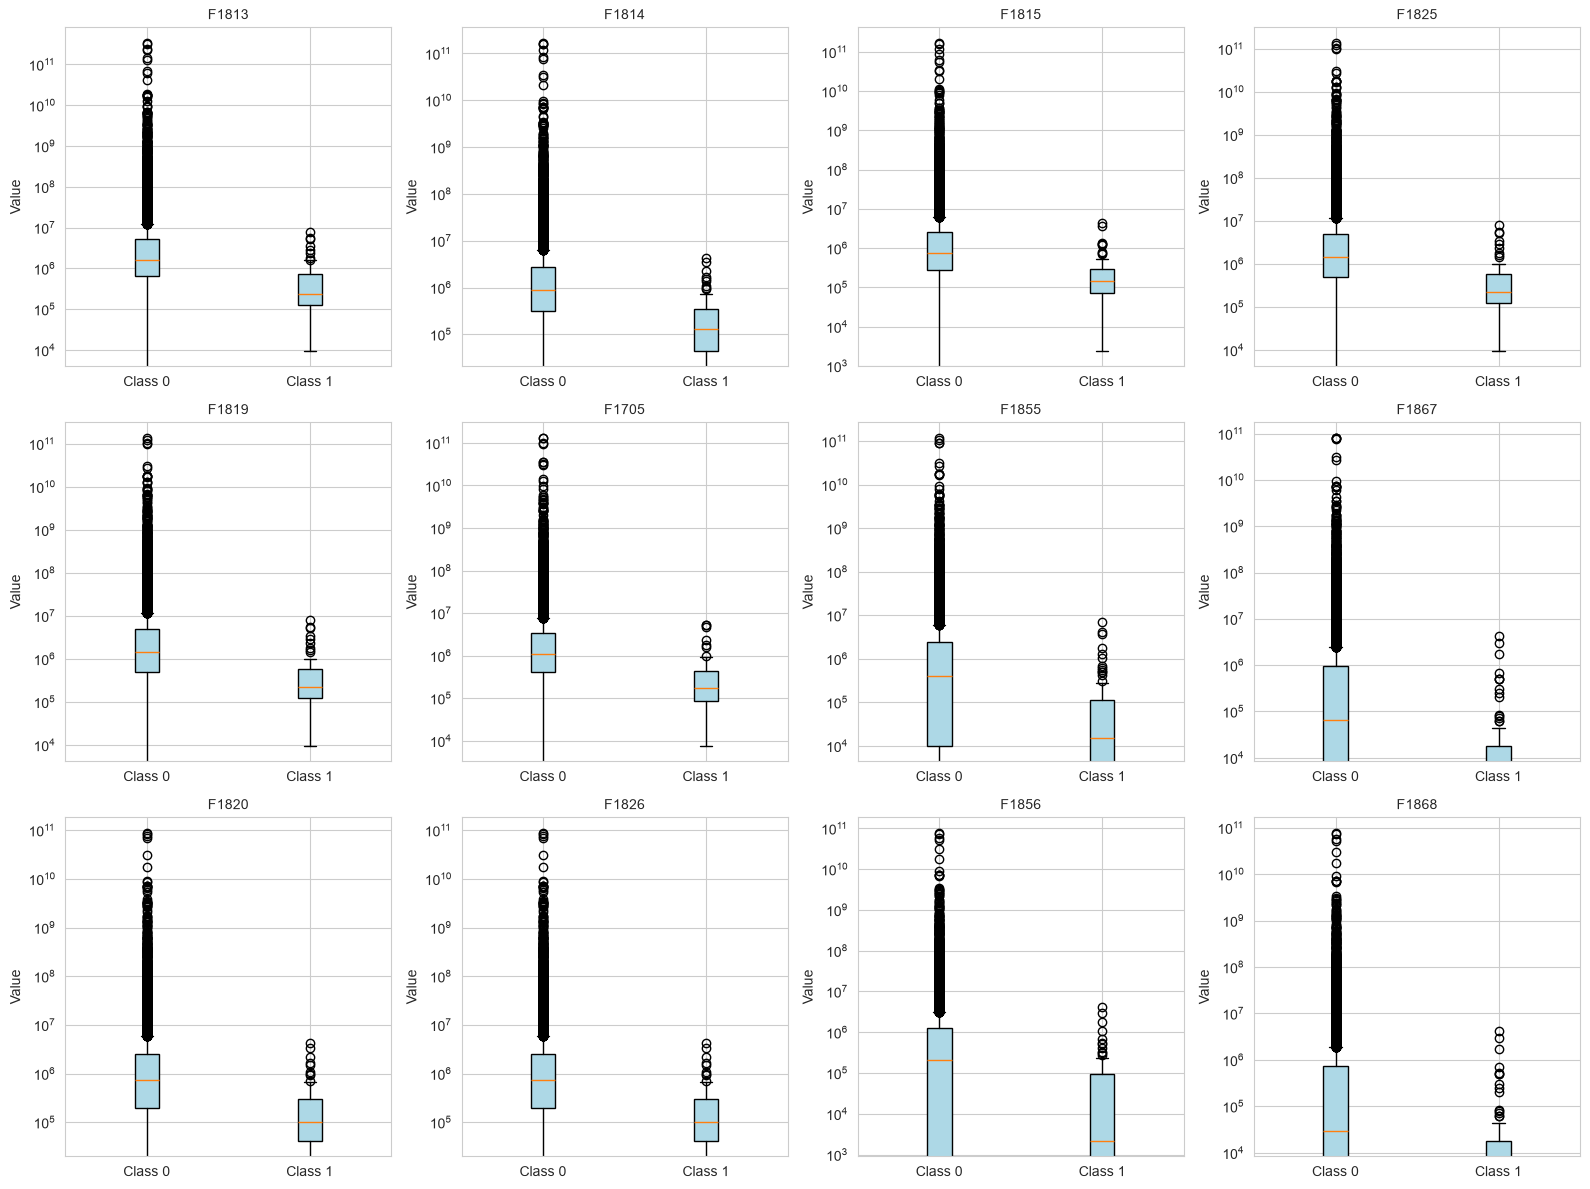


📊 Computing correlations with target...


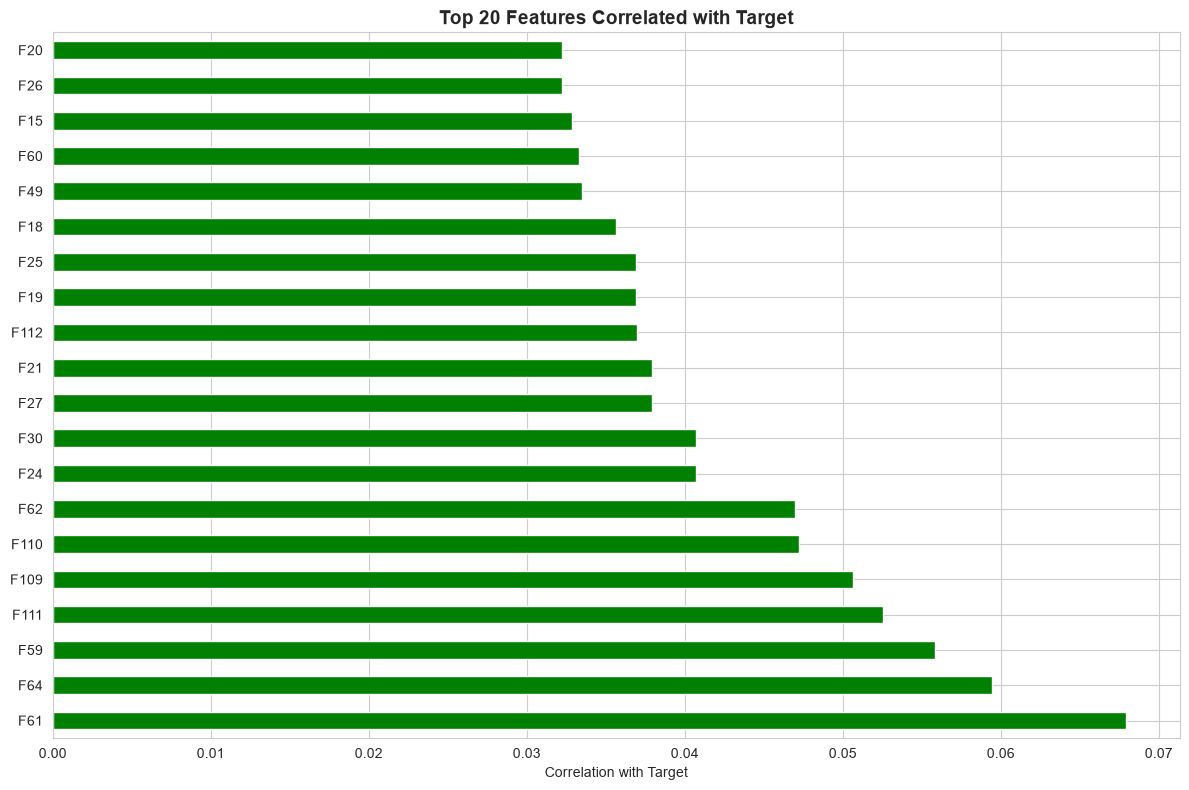

✅ EDA visualizations saved successfully!


In [20]:


def perform_eda(X, y, df_original, target_col):
    """
    Generate comprehensive EDA visualizations for large dataset
    """
    
    print("\n" + "=" * 70)
    print("EXPLORATORY DATA ANALYSIS")
    print("=" * 70)
    
    # 1. Target Distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1 = axes[0]
    y.value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'], ax=ax1)
    ax1.set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Class (0=Legitimate, 1=Suspicious)')
    ax1.set_ylabel('Count')
    ax1.set_xticklabels(['Legitimate', 'Suspicious'], rotation=0)
    for i, v in enumerate(y.value_counts().values):
        ax1.text(i, v + 10, str(v), ha='center', fontweight='bold')
    
    ax2 = axes[1]
    y.value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], ax=ax2)
    ax2.set_title('Class Percentage', fontsize=14, fontweight='bold')
    ax2.set_ylabel('')
    
    plt.tight_layout()
    plt.savefig('01_target_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 2. Identify top features by variance (for visualization)
    print("\n📊 Analyzing feature distributions...")
    feature_vars = X.var().sort_values(ascending=False)
    top_20_features = feature_vars.head(20).index.tolist()
    
    # 3. Box plots for top features
    n_features_to_plot = min(12, len(top_20_features))
    n_rows = (n_features_to_plot + 3) // 4
    fig, axes = plt.subplots(n_rows, 4, figsize=(16, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for idx, feature in enumerate(top_20_features[:n_features_to_plot]):
        data = []
        labels = []
        for class_val in sorted(y.unique()):
            subset = X[y == class_val][feature].dropna()
            if len(subset) > 0:
                data.append(subset)
                labels.append(f'Class {class_val}')
        
        bp = axes[idx].boxplot(data, tick_labels=labels, patch_artist=True,
                                boxprops=dict(facecolor='lightblue'))
        axes[idx].set_title(f'{feature[:30]}...' if len(feature) > 30 else feature, fontsize=10)
        axes[idx].set_ylabel('Value')
        if len(data) > 0 and data[0].max() > 1000:
            axes[idx].set_yscale('log')
    
    # Hide unused subplots
    for idx in range(n_features_to_plot, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('02_feature_boxplots.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 4. Correlation with target (sample features)
    print("\n📊 Computing correlations with target...")
    
    # Sample features for correlation (to avoid memory issues)
    n_corr_features = min(100, X.shape[1])
    sampled_features = X.columns[:n_corr_features].tolist()
    
    corr_data = pd.concat([X[sampled_features], y], axis=1)
    correlations = corr_data.corr()[target_col].drop(target_col).sort_values(ascending=False)
    
    plt.figure(figsize=(12, 8))
    top_corr = correlations.head(20)
    colors = ['red' if x < 0 else 'green' for x in top_corr.values]
    top_corr.plot(kind='barh', color=colors)
    plt.xlabel('Correlation with Target')
    plt.title('Top 20 Features Correlated with Target', fontsize=14, fontweight='bold')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.tight_layout()
    plt.savefig('03_feature_correlations.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✅ EDA visualizations saved successfully!")
    return correlations

# Run EDA
correlations = perform_eda(X_processed, y, df, target_col)

### 5. FEATURE ENGINEERING

In [21]:


def engineer_features(X, df_original):
    """
    Create engineered features for better prediction
    Memory efficient for large datasets
    """
    
    print("\n" + "=" * 70)
    print("FEATURE ENGINEERING")
    print("=" * 70)
    
    X_fe = X.copy()
    
    # Identify numeric columns that may represent amounts
    amount_keywords = ['F1', 'F2', 'F3', 'F4', 'F5', 'F100', 'F200', 'F300']
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    
    engineered_count = 0
    
    # 1. Create ratio features from first few F-series columns
    for i in range(1, min(20, len(numeric_cols)-1)):
        col1 = f'F{i}'
        col2 = f'F{i+1}'
        if col1 in X.columns and col2 in X.columns:
            ratio_col = f'ratio_F{i}_F{i+1}'
            X_fe[ratio_col] = X[col1] / (X[col2] + 1e-6)
            engineered_count += 1
            
            # Log transform of ratio
            X_fe[f'{ratio_col}_log'] = np.log1p(X_fe[ratio_col])
            engineered_count += 1
    
    print(f"✅ Created {engineered_count} ratio features")
    
    # 2. Create interaction features for high-variance columns
    feature_vars = X.var().sort_values(ascending=False)
    top_variance = feature_vars.head(30).index.tolist()
    
    interaction_count = 0
    for i in range(min(10, len(top_variance))):
        for j in range(i+1, min(i+5, len(top_variance))):
            col1, col2 = top_variance[i], top_variance[j]
            interaction_col = f'interaction_{col1}_{col2}'
            X_fe[interaction_col] = X[col1] * X[col2]
            interaction_count += 1
    
    print(f"✅ Created {interaction_count} interaction features")
    
    # 3. Create polynomial features for top features
    poly_count = 0
    for col in top_variance[:10]:
        X_fe[f'{col}_squared'] = X[col] ** 2
        X_fe[f'{col}_sqrt'] = np.sqrt(np.abs(X[col]) + 1e-6)
        poly_count += 2
    
    print(f"✅ Created {poly_count} polynomial features")
    
    # 4. Create aggregate features (row-wise statistics)
    X_fe['row_sum'] = X[numeric_cols].sum(axis=1)
    X_fe['row_mean'] = X[numeric_cols].mean(axis=1)
    X_fe['row_std'] = X[numeric_cols].std(axis=1)
    X_fe['row_min'] = X[numeric_cols].min(axis=1)
    X_fe['row_max'] = X[numeric_cols].max(axis=1)
    X_fe['row_range'] = X_fe['row_max'] - X_fe['row_min']
    
    print(f"✅ Created 6 aggregate features")
    
    # 5. Log transform for skewed features
    skewed_features = []
    for col in numeric_cols[:50]:  # Limit to first 50 to save time
        if col in X.columns:
            skewness = X[col].skew()
            if abs(skewness) > 2:
                X_fe[f'{col}_log'] = np.log1p(X[col])
                skewed_features.append(col)
    
    print(f"✅ Created {len(skewed_features)} log-transformed features for skewed columns")
    
    # Memory cleanup
    gc.collect()
    
    print(f"\n✅ Final feature count: {X_fe.shape[1]:,}")
    print(f"✅ Original features: {X.shape[1]:,}")
    print(f"✅ New engineered features: {X_fe.shape[1] - X.shape[1]:,}")
    
    return X_fe

# Apply feature engineering
X_engineered = engineer_features(X_processed, df)


FEATURE ENGINEERING
✅ Created 38 ratio features
✅ Created 40 interaction features
✅ Created 20 polynomial features
✅ Created 6 aggregate features
✅ Created 22 log-transformed features for skewed columns

✅ Final feature count: 3,095
✅ Original features: 2,969
✅ New engineered features: 126


### 6. FEATURE SELECTION (Optimized for Large Data)



FEATURE SELECTION

📊 Step 1: Removing constant features...
  ✅ Before: 3,095 features → After: 3,093 features
  ✅ Removed 2 constant features

📊 Step 2: Computing Mutual Information scores...

  Top 15 features by Mutual Information:
    1. row_mean...: 0.0146
    2. row_sum...: 0.0146
    3. row_range...: 0.0121
    4. row_std...: 0.0117
    5. row_max...: 0.0114
    6. F3484...: 0.0108
    7. F1863...: 0.0102
    8. interaction_F1826_F3799...: 0.0095
    9. F1501...: 0.0085
    10. F1381...: 0.0082
    11. F1495...: 0.0081
    12. F1827...: 0.0079
    13. F1821...: 0.0079
    14. F1489...: 0.0079
    15. F1755...: 0.0078

  ✅ Selected 100 features by Mutual Information

📊 Step 3: Recursive Feature Elimination (RFE)...
  ✅ Final selected features: 50

📊 Step 4: Generating feature importance plot...


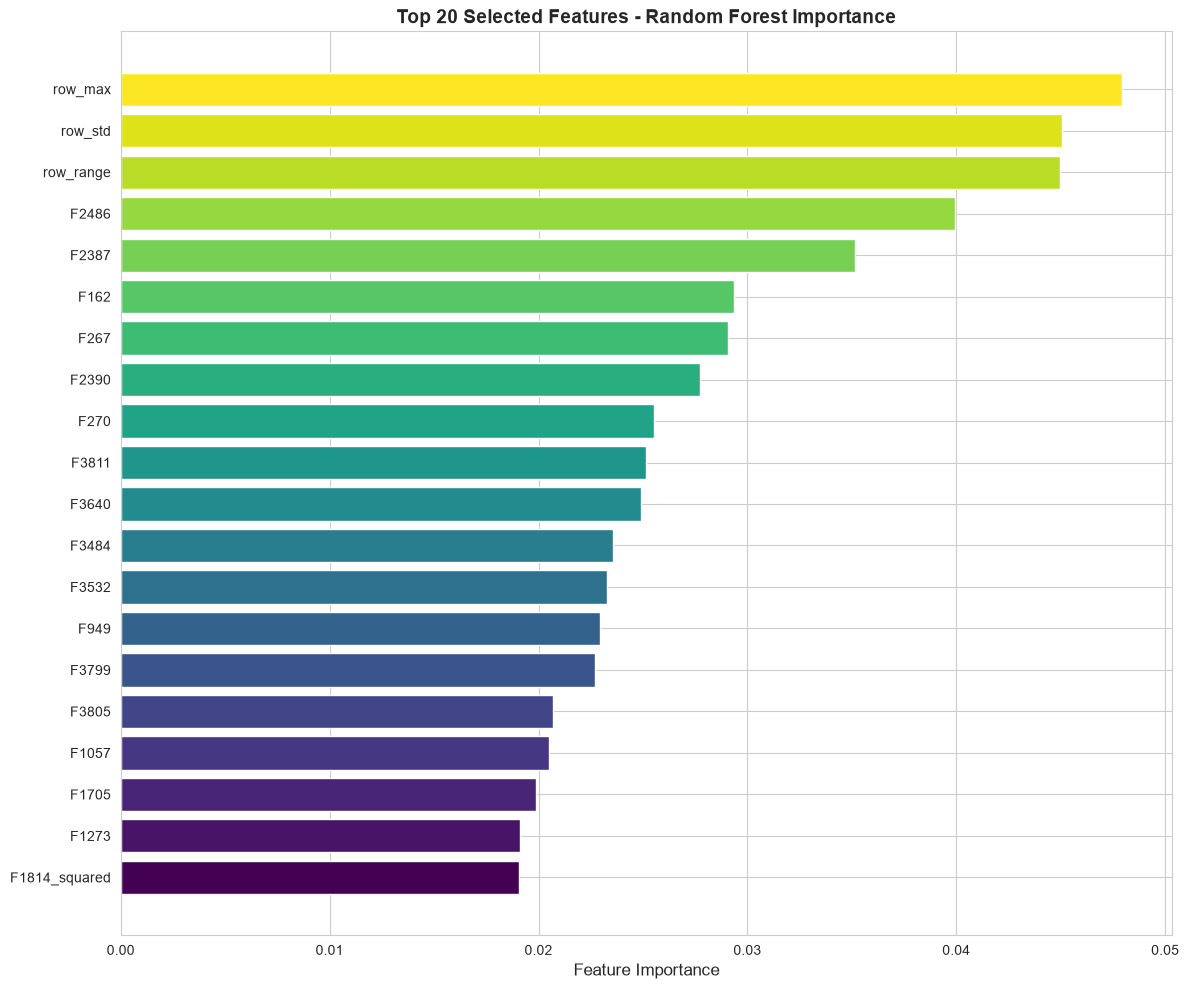


✅ Feature selection complete!
📊 Final dataset: 50 features

✓ Selected features: 50
✓ First 10 features: ['row_mean', 'row_sum', 'row_range', 'row_std', 'row_max', 'F3484', 'interaction_F1826_F3799', 'F1501', 'F1489', 'F1597']


In [22]:


def select_features(X, y, n_features=100):
    """
    Select top features using multiple methods
    Optimized for large feature space
    """
    
    print("\n" + "=" * 70)
    print("FEATURE SELECTION")
    print("=" * 70)
    
    # 1. Remove constant and quasi-constant features
    print("\n📊 Step 1: Removing constant features...")
    var_threshold = VarianceThreshold(threshold=0.01)
    X_var = var_threshold.fit_transform(X)
    selected_cols = X.columns[var_threshold.get_support()].tolist()
    X_filtered = X[selected_cols]
    print(f"  ✅ Before: {X.shape[1]:,} features → After: {X_filtered.shape[1]:,} features")
    print(f"  ✅ Removed {X.shape[1] - X_filtered.shape[1]:,} constant features")
    
    # 2. Mutual Information scores (for non-linear relationships)
    print("\n📊 Step 2: Computing Mutual Information scores...")
    mi_scores = mutual_info_classif(X_filtered, y, random_state=42, n_jobs=-1)
    mi_series = pd.Series(mi_scores, index=X_filtered.columns).sort_values(ascending=False)
    
    print(f"\n  Top 15 features by Mutual Information:")
    for i, (feat, score) in enumerate(mi_series.head(15).items()):
        print(f"    {i+1}. {feat[:40]}...: {score:.4f}")
    
    # 3. Select top features by MI
    top_mi_features = mi_series.head(n_features).index.tolist()
    X_mi = X_filtered[top_mi_features]
    print(f"\n  ✅ Selected {len(top_mi_features)} features by Mutual Information")
    
    # 4. RFE with Random Forest (for final selection)
    print("\n📊 Step 3: Recursive Feature Elimination (RFE)...")
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    
    final_n_features = min(50, len(top_mi_features))
    rfe = RFE(estimator=rf, n_features_to_select=final_n_features, step=10)
    rfe.fit(X_mi, y)
    
    final_features = X_mi.columns[rfe.support_].tolist()
    X_final = X_mi[final_features]
    
    print(f"  ✅ Final selected features: {len(final_features)}")
    
    # 5. Feature importance visualization
    print("\n📊 Step 4: Generating feature importance plot...")
    
    # Train a quick Random Forest on final features
    rf_final = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_final.fit(X_final, y)
    
    importance_df = pd.DataFrame({
        'feature': final_features,
        'importance': rf_final.feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(12, 10))
    top_20_imp = importance_df.head(20)
    colors = plt.cm.viridis(np.linspace(0, 1, len(top_20_imp)))
    plt.barh(range(len(top_20_imp)), top_20_imp['importance'].values, color=colors[::-1])
    plt.yticks(range(len(top_20_imp)), top_20_imp['feature'].values)
    plt.xlabel('Feature Importance', fontsize=12)
    plt.title('Top 20 Selected Features - Random Forest Importance', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('04_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n✅ Feature selection complete!")
    print(f"📊 Final dataset: {X_final.shape[1]:,} features")
    
    return X_final, final_features, importance_df

# Apply feature selection
X_selected, selected_features, importance_df = select_features(X_engineered, y, n_features=100)

print(f"\n✓ Selected features: {len(selected_features)}")
print(f"✓ First 10 features: {selected_features[:10]}")

c:\ML\.venv\Scripts\python.exe
